# Validation and Evaluation Plots for HAM10000 - model_v2_mel_sensitive_final

This notebook loads the evaluation artifacts from `reports/model_v2_mel_sensitive_final` and visualizes the main metrics, confusion matrices, and training curves for the melanoma-sensitive `v2` model.

In [3]:
from pathlib import Path
import json

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Image

plt.style.use('seaborn-v0_8-whitegrid')
base_dir = Path(r'c:\Users\mari0\OneDrive\Documentos\INSPER\8 SEMESTRE\ARITIFICIAL INTELLIGENCE\Projeto_Artificial_Intelligence\reports\model_v2_mel_sensitive_final')
baseline_dir = Path(r'c:\Users\mari0\OneDrive\Documentos\INSPER\8 SEMESTRE\ARITIFICIAL INTELLIGENCE\Projeto_Artificial_Intelligence\reports\model_v1')

metrics_v2_path = base_dir / 'metrics_v2.json'
report_v2_path = base_dir / 'classification_report_v2.csv'
cm_v2_path = base_dir / 'confusion_matrix_v2.csv'
history_image_v2_path = base_dir / 'training_history_v2.png'
compact_history_image_v2_path = base_dir / 'training_history_compact_v2.png'

metrics_v1_path = baseline_dir / 'metrics_v1.json'
report_v1_path = baseline_dir / 'classification_report_v1.csv'
cm_v1_path = baseline_dir / 'confusion_matrix_v1.csv'
history_image_v1_path = baseline_dir / 'training_history_v1.png'
compact_history_image_v1_path = baseline_dir / 'training_history_compact_v1.png'

metrics_v2 = json.loads(metrics_v2_path.read_text(encoding='utf-8'))
report_v2_df = pd.read_csv(report_v2_path, index_col=0)
cm_v2_df = pd.read_csv(cm_v2_path, index_col=0)

metrics_v1 = json.loads(metrics_v1_path.read_text(encoding='utf-8'))
report_v1_df = pd.read_csv(report_v1_path, index_col=0)
cm_v1_df = pd.read_csv(cm_v1_path, index_col=0)

metrics_v2

{'accuracy': 0.7045908183632734,
 'recall_macro': 0.6358412678810368,
 'recall_weighted': 0.7045908183632734,
 'precision_macro': 0.6655050100057609,
 'precision_weighted': 0.8143247267650882,
 'f1_macro': 0.6262296524357982,
 'f1_weighted': 0.7339370317541974,
 'roc_auc_ovr_macro': 0.9405627868381414,
 'roc_auc_ovr_weighted': 0.9317781372914109,
 'recall_melanoma': 0.7485029940119761,
 'precision_melanoma': 0.3324468085106383,
 'f1_melanoma': 0.4604051565377532,
 'melanoma_threshold': 0.36}

In [4]:
# Comparison of the most relevant metrics between v1 and v2
comparison_keys = [
    ('recall_melanoma', 'Recall melanoma'),
    ('recall_macro', 'Recall macro'),
    ('precision_macro', 'Precision macro'),
    ('f1_macro', 'F1 macro'),
    ('roc_auc_ovr_macro', 'ROC-AUC OVR macro'),
]

comparison_df = pd.DataFrame(
    {
        'Metric': [label for _, label in comparison_keys],
        'v1': [metrics_v1.get(key, 0.0) for key, _ in comparison_keys],
        'v2': [metrics_v2.get(key, 0.0) for key, _ in comparison_keys],
    }
)
comparison_df['Delta (v2 - v1)'] = comparison_df['v2'] - comparison_df['v1']
comparison_df

,Metric,v1,v2,Delta (v2 - v1)
0,Recall melanoma,0.982036,0.748503,-0.233533
1,Recall macro,0.145545,0.635841,0.490296
2,Precision macro,0.155156,0.665505,0.510349
3,F1 macro,0.038943,0.626230,0.587286
4,ROC-AUC OVR macro,0.648748,0.940563,0.291815


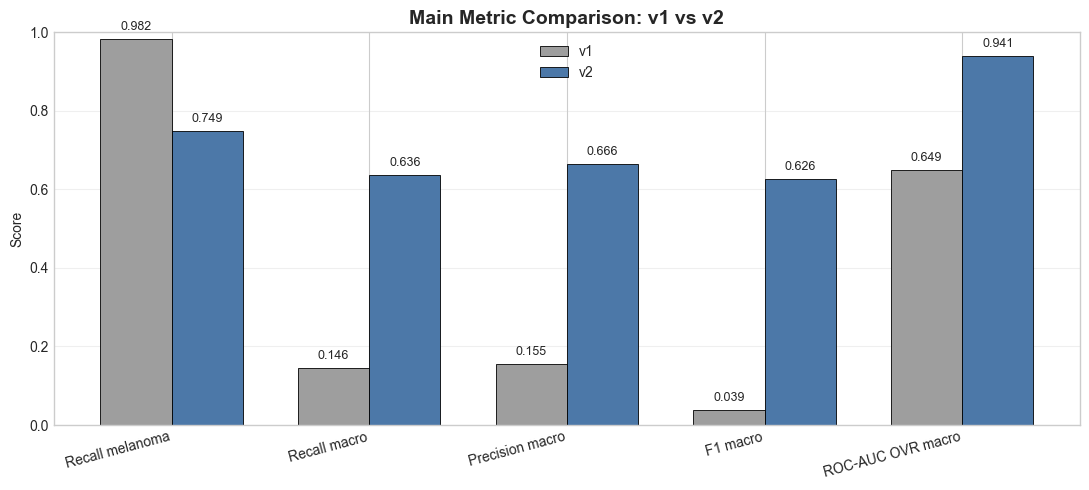

In [5]:
# Comparison plot: v1 vs v2 for the main metrics
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(comparison_df))
width = 0.36

bars_v1 = ax.bar(x - width / 2, comparison_df['v1'], width, label='v1', color='#9E9E9E', edgecolor='black', linewidth=0.6)
bars_v2 = ax.bar(x + width / 2, comparison_df['v2'], width, label='v2', color='#4C78A8', edgecolor='black', linewidth=0.6)

ax.set_ylim(0, 1)
ax.set_title('Main Metric Comparison: v1 vs v2', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], rotation=15, ha='right')
ax.grid(True, axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

for bars in (bars_v1, bars_v2):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9,
        )

plt.tight_layout()
plt.show()

In [6]:
# Per-class comparison from both classification reports
class_rows_v1 = [idx for idx in report_v1_df.index if idx not in ['accuracy', 'macro avg', 'weighted avg']]
class_rows_v2 = [idx for idx in report_v2_df.index if idx not in ['accuracy', 'macro avg', 'weighted avg']]
class_rows = [idx for idx in class_rows_v1 if idx in class_rows_v2]

class_comparison = pd.DataFrame(
    {
        'precision_v1': report_v1_df.loc[class_rows, 'precision'],
        'recall_v1': report_v1_df.loc[class_rows, 'recall'],
        'f1_v1': report_v1_df.loc[class_rows, 'f1-score'],
        'precision_v2': report_v2_df.loc[class_rows, 'precision'],
        'recall_v2': report_v2_df.loc[class_rows, 'recall'],
        'f1_v2': report_v2_df.loc[class_rows, 'f1-score'],
    }
)
class_comparison

,precision_v1,recall_v1,f1_v1,precision_v2,recall_v2,f1_v2
akiec,0.000000,0.000000,0.000000,0.742857,0.530612,0.619048
bcc,0.000000,0.000000,0.000000,0.662162,0.636364,0.649007
bkl,0.000000,0.000000,0.000000,0.495968,0.745455,0.595642
df,0.000000,0.000000,0.000000,0.461538,0.352941,0.400000
mel,0.112406,0.982036,0.201722,0.332447,0.748503,0.460405
nv,0.973684,0.036779,0.070881,0.963563,0.709742,0.817401
vasc,0.000000,0.000000,0.000000,1.000000,0.727273,0.842105


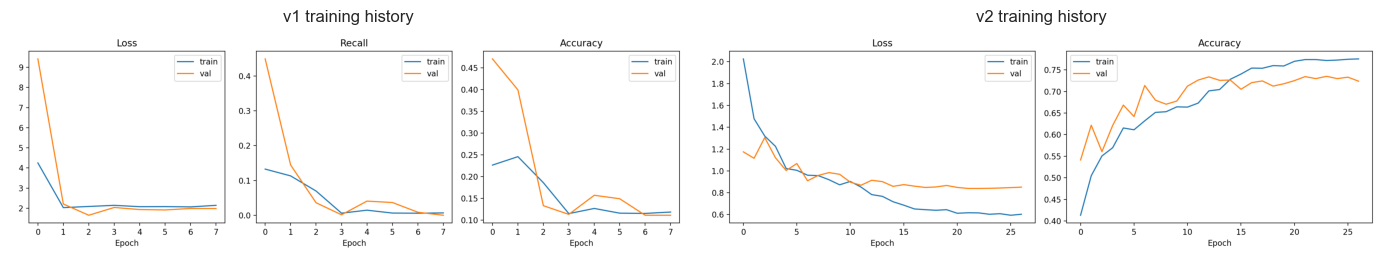

In [7]:
# Display the saved training history figures if they exist
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if history_image_v1_path.exists():
    axes[0].imshow(mpimg.imread(str(history_image_v1_path)))
    axes[0].set_title('v1 training history')
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'training_history_v1.png not found', ha='center', va='center')
    axes[0].axis('off')

if history_image_v2_path.exists():
    axes[1].imshow(mpimg.imread(str(history_image_v2_path)))
    axes[1].set_title('v2 training history')
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'training_history_v2.png not found', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

if compact_history_image_v1_path.exists():
    display(Image(filename=str(compact_history_image_v1_path)))

if compact_history_image_v2_path.exists():
    display(Image(filename=str(compact_history_image_v2_path)))

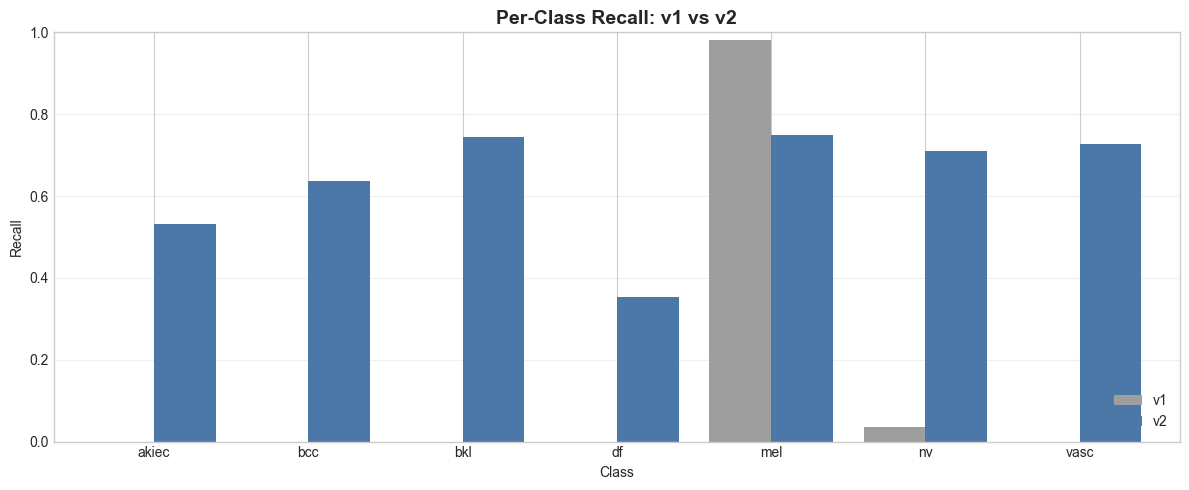

,v1,v2
mel,0.982036,0.748503


In [8]:
# Per-class recall comparison, highlighting melanoma sensitivity
recall_comparison = pd.DataFrame(
    {
        'v1': report_v1_df.loc[class_rows, 'recall'],
        'v2': report_v2_df.loc[class_rows, 'recall'],
    }
)

ax = recall_comparison.plot(kind='bar', figsize=(12, 5), width=0.8, color=['#9E9E9E', '#4C78A8'])
ax.set_title('Per-Class Recall: v1 vs v2', fontsize=14, fontweight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Recall')
ax.set_ylim(0, 1)
ax.set_xticklabels(recall_comparison.index, rotation=0)
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

recall_comparison.loc[['mel'] if 'mel' in recall_comparison.index else recall_comparison.index]